In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set

<function seaborn.rcmod.set(*args, **kwargs)>

In [3]:
df = pd.read_csv('dynamic_pricing.csv')
print(df.shape)
df.head()

/content/drive/MyDrive/Data Sets
(1000, 10)


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [5]:
df.isnull().sum()

,0
Number_of_Riders,0
Number_of_Drivers,0
Location_Category,0
Customer_Loyalty_Status,0
Number_of_Past_Rides,0
Average_Ratings,0
Time_of_Booking,0
Vehicle_Type,0
Expected_Ride_Duration,0
Historical_Cost_of_Ride,0


In [6]:
df.describe(include='number')

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


# Data Distribution

In [7]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print(numeric_cols)
print(cat_cols)

['Number_of_Riders', 'Number_of_Drivers', 'Number_of_Past_Rides', 'Average_Ratings', 'Expected_Ride_Duration', 'Historical_Cost_of_Ride']
['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking', 'Vehicle_Type']


Let's see for Numeric Cols first .....

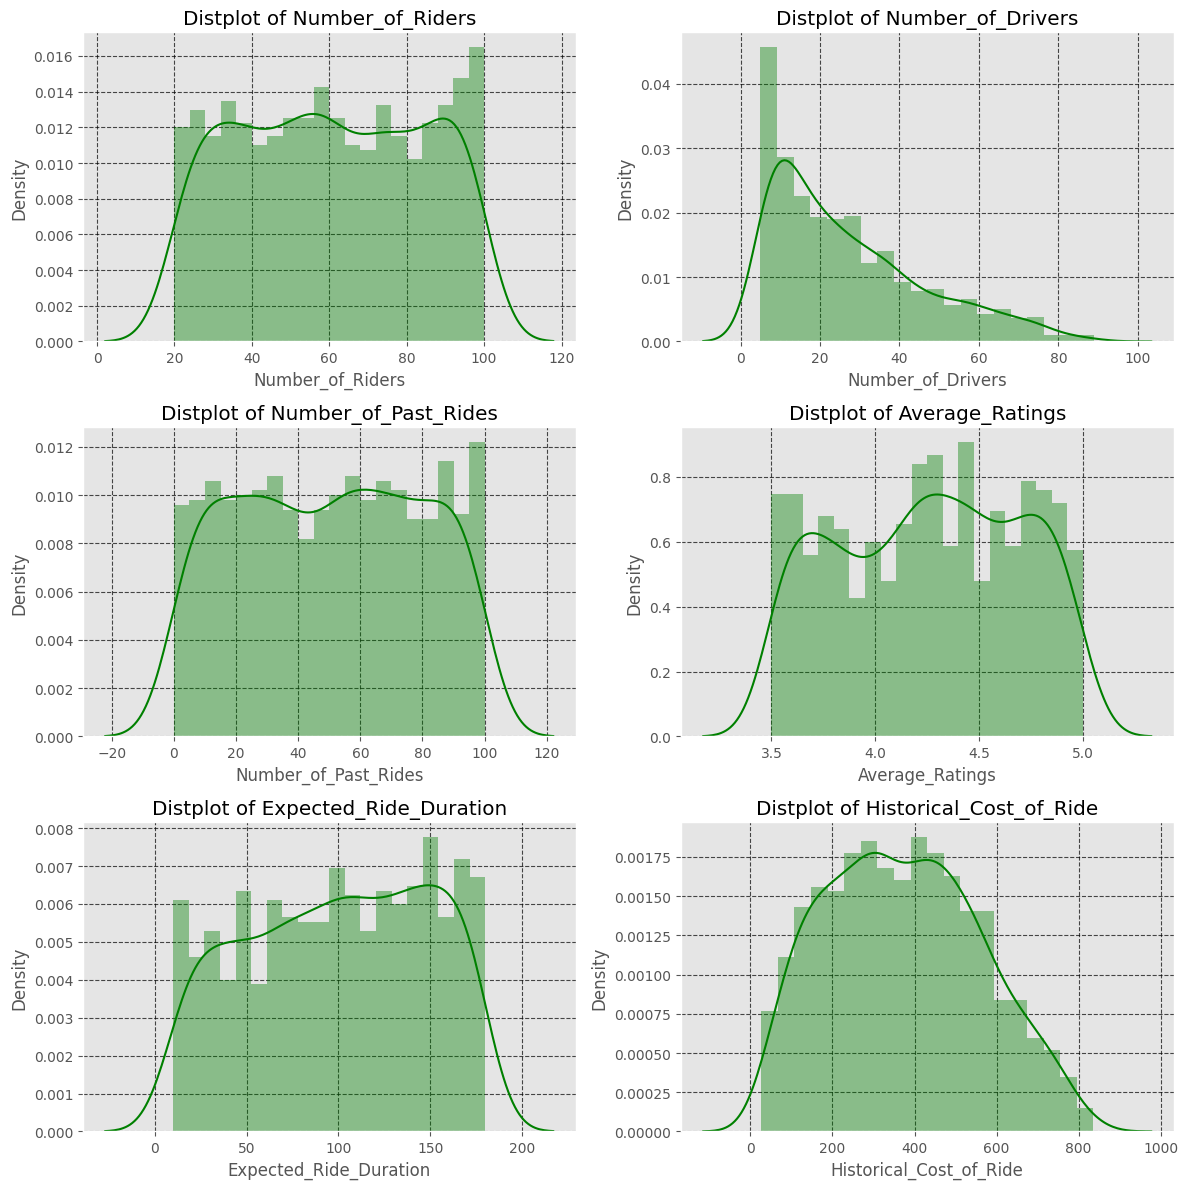

In [8]:
# Distplot for numeric_cols
import math
num_cols = len(numeric_cols)
grid_cols = 2
grid_rows = math.ceil(num_cols/grid_cols)
# plt.figure(figsize=(grid_cols*5, grid_rows*4))
plt.figure(figsize=(grid_rows*4, grid_cols*6))
for i, col in enumerate(numeric_cols):
  plt.subplot(grid_rows, grid_cols, i+1)
  sns.distplot(df[col], bins=20, color='green')
  plt.title(f"Distplot of {col}")
  plt.grid(linestyle='--', color='black',  alpha=0.7)
plt.tight_layout()
plt.show()

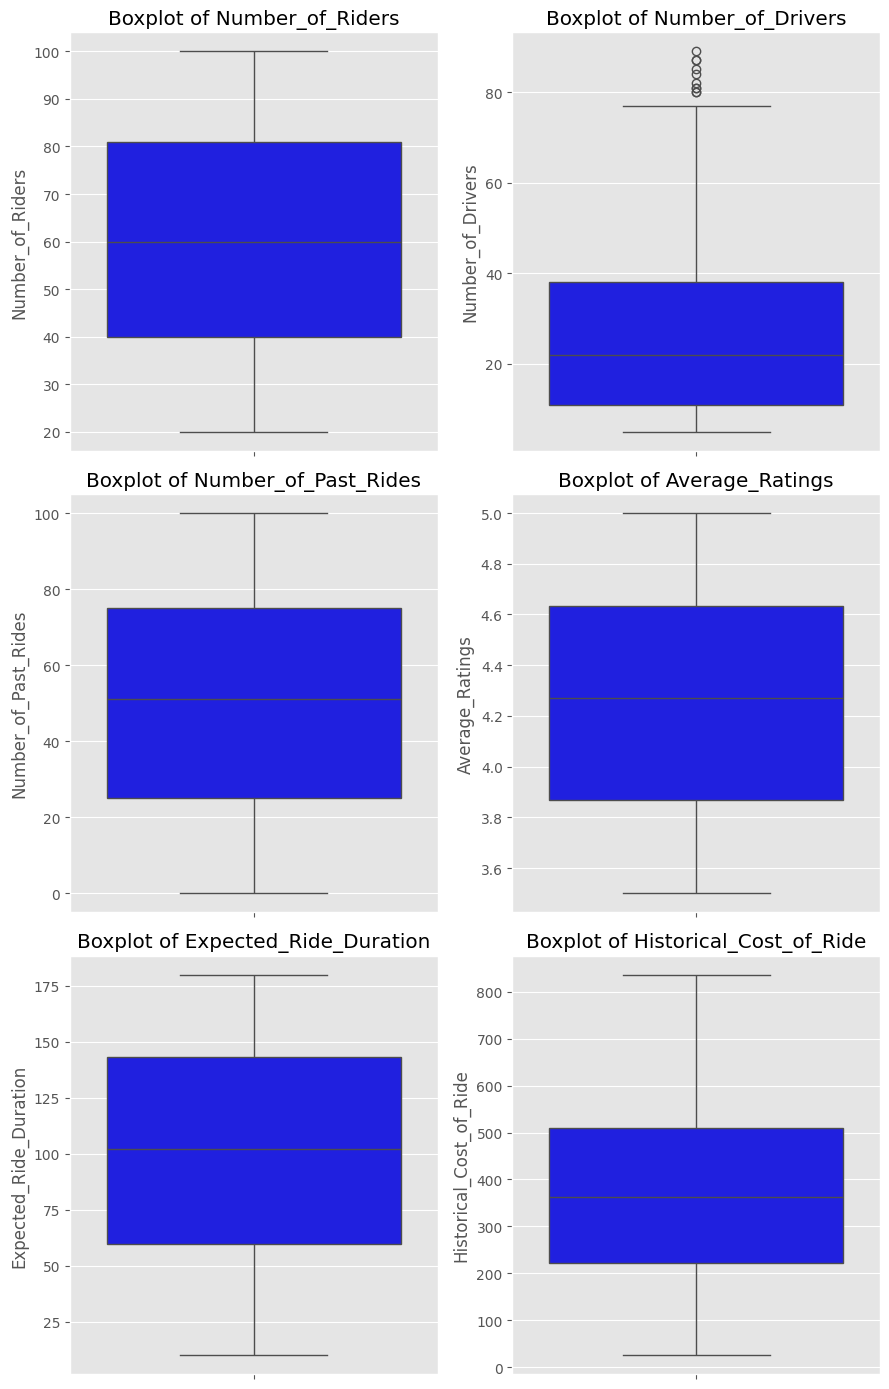

In [9]:
# Boxplot for numeric_cols
num_cols = len(numeric_cols)
grid_cols =2
grid_rows = math.ceil(num_cols/grid_cols)
plt.figure(figsize=(grid_rows*3, grid_cols*7))
for i, col in enumerate(numeric_cols):
  plt.subplot(grid_rows, grid_cols, i+1)
  sns.boxplot(df[col], color='blue')
  plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

Let's see the distribution of Categorical Cols .....

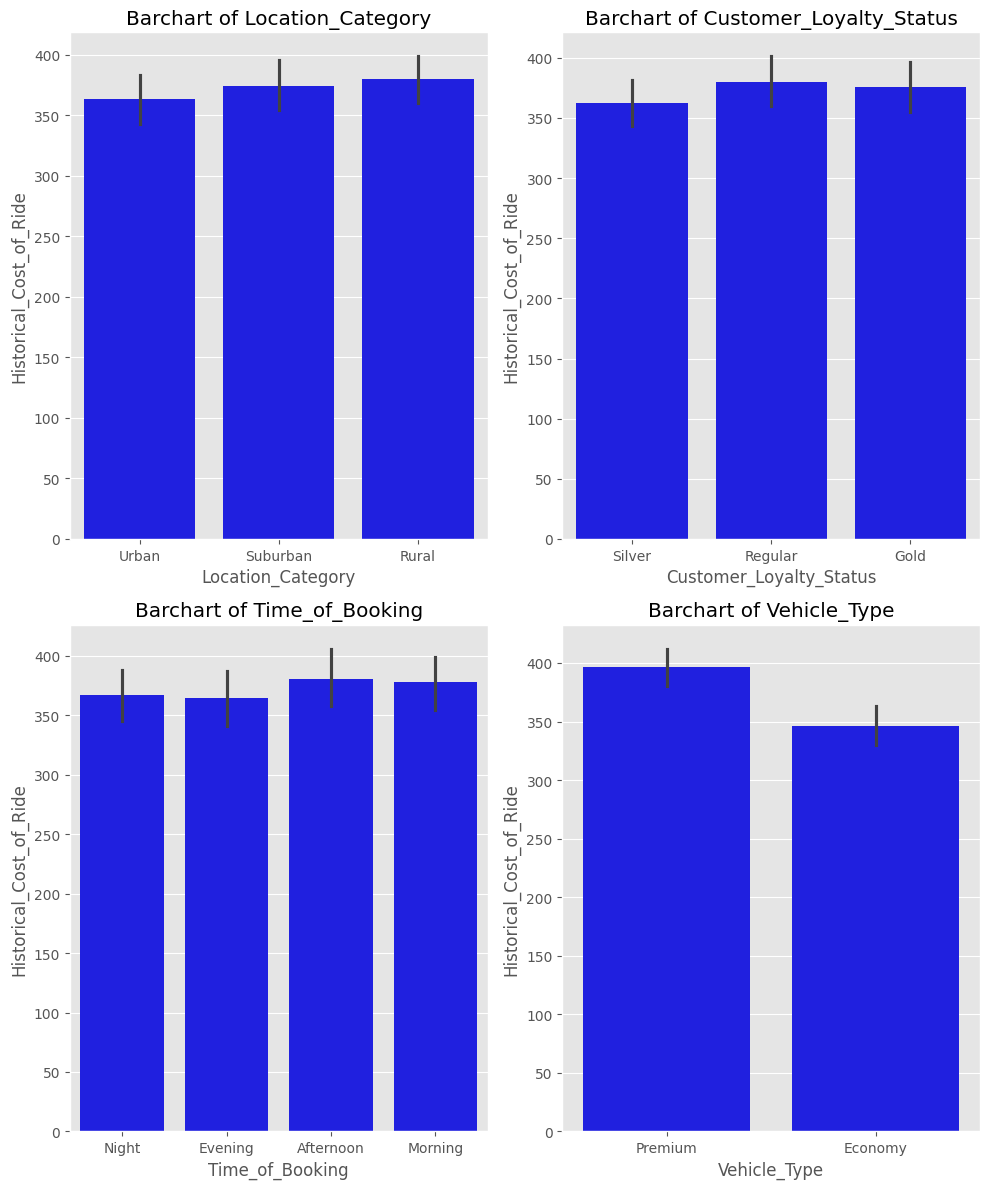

In [10]:
# Barplot of cat vars.
num_cols = len(cat_cols)
grid_cols = 2
grid_rows = math.ceil(num_cols/grid_cols)
plt.figure(figsize=(grid_rows*5, grid_cols*6))
for i, col in enumerate(cat_cols):
  plt.subplot(grid_rows, grid_cols, i+1)
  sns.barplot(x = col, y='Historical_Cost_of_Ride', data=df, color='blue')
  plt.title(f"Barchart of {col}")
plt.tight_layout()
plt.show()

Now see the Correlation variables with Taget variable......

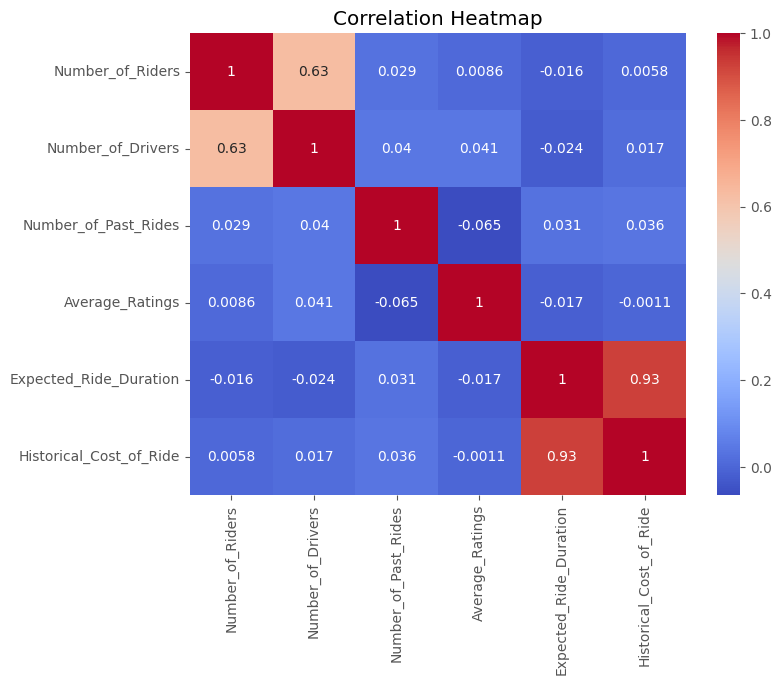

In [11]:
# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

As we see that two features (Number_of_Drivers, Average_Ratings) are weakly correlated with target var so we drop them.

In [12]:
df_2 = df.drop(['Number_of_Drivers', 'Average_Ratings'], axis=1)
print(df_2.shape)
df_2.head(5)

(1000, 8)


,Number_of_Riders,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,Urban,Silver,13,Night,Premium,90,284.257273
1,58,Suburban,Silver,72,Evening,Economy,43,173.874753
2,42,Rural,Silver,0,Afternoon,Premium,76,329.795469
3,89,Rural,Regular,67,Afternoon,Premium,134,470.201232
4,78,Rural,Regular,74,Afternoon,Economy,149,579.681422


<Figure size 1200x1000 with 0 Axes>

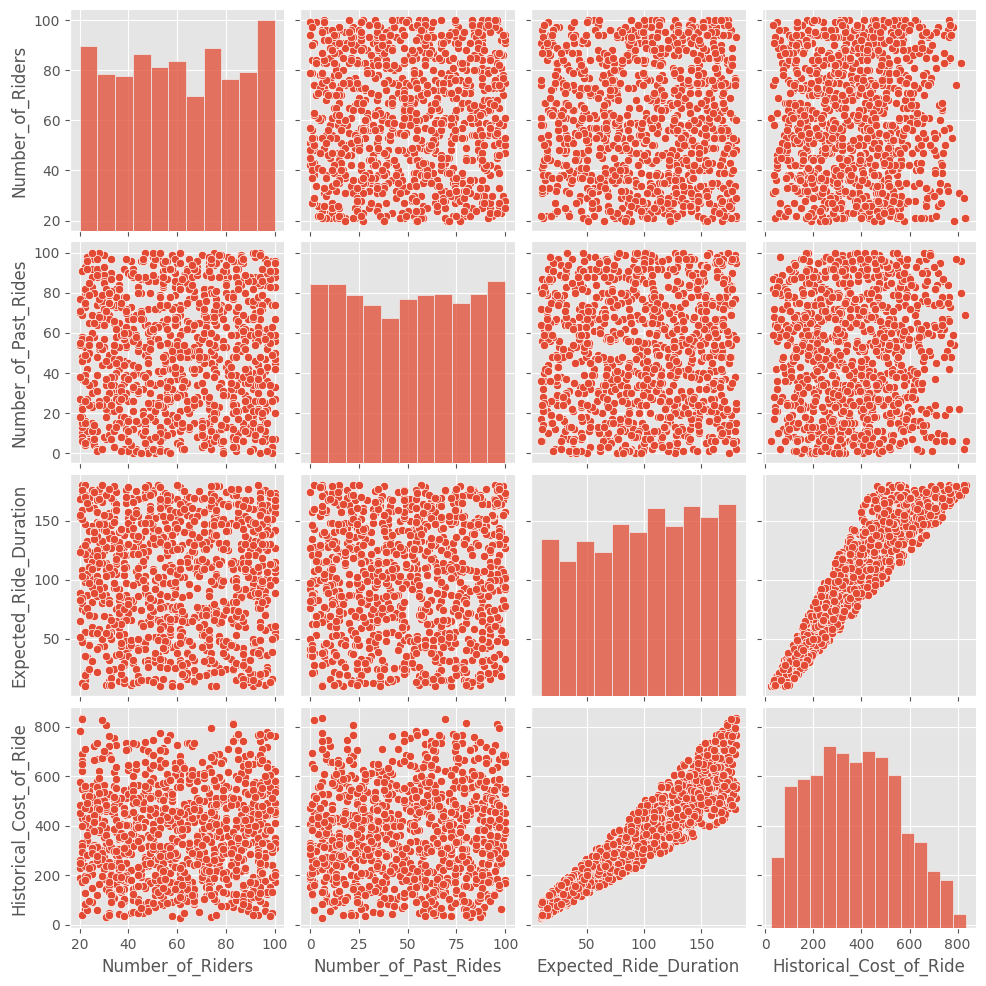

In [13]:
plt.figure(figsize=(12,10))
sns.pairplot(df_2)
plt.show()

# One Hot Encoding

In [14]:
df_3 = pd.get_dummies(df_2, drop_first=True)
print(df_3.shape)
df_3.head(5)

(1000, 12)


,Number_of_Riders,Number_of_Past_Rides,Expected_Ride_Duration,Historical_Cost_of_Ride,Location_Category_Suburban,Location_Category_Urban,Customer_Loyalty_Status_Regular,Customer_Loyalty_Status_Silver,Time_of_Booking_Evening,Time_of_Booking_Morning,Time_of_Booking_Night,Vehicle_Type_Premium
0,90,13,90,284.257273,False,True,False,True,False,False,True,True
1,58,72,43,173.874753,True,False,False,True,True,False,False,False
2,42,0,76,329.795469,False,False,False,True,False,False,False,True
3,89,67,134,470.201232,False,False,True,False,False,False,False,True
4,78,74,149,579.681422,False,False,True,False,False,False,False,False


In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df_3.drop('Historical_Cost_of_Ride', axis=1).astype(int),
                                                    df_3['Historical_Cost_of_Ride'].astype(int),
                                                    test_size=0.2, random_state=42 )


# Let's Apply Individual Models...

As Target var. is numerical so we shall continue with Regression Models.

In [16]:
# Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [17]:
print(f" Train score : {model.score(x_train, y_train)}")
print(f" Test score : {model.score(x_test, y_test)}")

 Train score : 0.875372094393862
 Test score : 0.8769356092678069


In [18]:
# KNN
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor()
model.fit(x_train,y_train)

KNeighborsRegressor()

In [19]:
print(f" Train score : {model.score(x_train, y_train)}")
print(f" Test score : {model.score(x_test, y_test)}")

 Train score : 0.885539552578472
 Test score : 0.8541296535779462


In [20]:
# SVR
from sklearn.svm import SVR
model = SVR(C=1.0, kernel='linear')
model.fit(x_train,y_train)

SVR(kernel='linear')

In [21]:
print(f" Train score : {model.score(x_train, y_train)}")
print(f" Test score : {model.score(x_test, y_test)}")

 Train score : 0.8738263163061324
 Test score : 0.8752793629097962


In [22]:
# DecisionTree
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth=2)
model.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=2)

In [23]:
print(f" Train score : {model.score(x_train, y_train)}")
print(f" Test score : {model.score(x_test, y_test)}")

 Train score : 0.8112356779972921
 Test score : 0.8054446238441949


In [24]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, max_depth=2)
model.fit(x_train, y_train)

RandomForestRegressor(max_depth=2)

In [25]:
print(f" Train score : {model.score(x_train, y_train)}")
print(f" Test score : {model.score(x_test, y_test)}")

 Train score : 0.839449645618415
 Test score : 0.8396062861610549


In [26]:
# XGBoost
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators= 30, max_depth=2)
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=30,
             n_jobs=None, num_parallel_tree=None, ...)

In [27]:
print(f" Train score : {model.score(x_train, y_train)}")
print(f" Test score : {model.score(x_test, y_test)}")

 Train score : 0.8920499086380005
 Test score : 0.8624817132949829


In [28]:
# LightGBM
from lightgbm import LGBMRegressor
model = LGBMRegressor(n_estimators=100, max_depth=2, verbose=-1)
model.fit(x_train, y_train)

LGBMRegressor(max_depth=2, verbose=-1)

In [29]:
print(f" Train score : {model.score(x_train, y_train)}")
print(f" Test score : {model.score(x_test, y_test)}")

 Train score : 0.8904204363701632
 Test score : 0.867429325324492


In [30]:
# AdaBoost
from sklearn.ensemble import AdaBoostRegressor
model = AdaBoostRegressor()
model.fit(x_train, y_train)

AdaBoostRegressor()

In [31]:
print(f" Train score : {model.score(x_train, y_train)}")
print(f" Test score : {model.score(x_test, y_test)}")

 Train score : 0.8741107570145925
 Test score : 0.8624140665171419


In [32]:
# Gradient Boost
from sklearn.ensemble import GradientBoostingRegressor
model= GradientBoostingRegressor(n_estimators=100, max_depth=2)
model.fit(x_train, y_train)

GradientBoostingRegressor(max_depth=2)

In [33]:
print(f" Train score : {model.score(x_train, y_train)}")
print(f" Test score : {model.score(x_test, y_test)}")

 Train score : 0.8952590856640528
 Test score : 0.8579837144453327


# Applying Deep Learning

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
# Model Building
model = Sequential([
    Dense(128, activation= 'relu', input_shape=(x_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [35]:
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1, callbacks=[early_stop])
history_df = pd.DataFrame(history.history)
print(f"\n Epoch wise raw data in last 5 rows : \n {history_df.tail()}")

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 327.5997 - val_loss: 252.2297
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 162.6286 - val_loss: 99.1290
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92.9024 - val_loss: 69.2709
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 69.9711 - val_loss: 52.2600
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 62.1995 - val_loss: 50.3575
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 62.3412 - val_loss: 50.1013
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 60.2277 - val_loss: 50.3182
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 59.8610 - val_loss: 50.0208
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 62.5646 - val_loss: 50.3541
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 60.0354 - val_loss: 50.5338
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 57.4064 - val_loss: 51.8946
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━

We see that Deep Learning isn't giving so good score beacuse it's a small Data Set.

#Apply PipeLine to select the best model

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Imported Models.....
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import GridSearchCV

# Prepared Base Pipeline.....
base_pipeline = Pipeline([
        ('model', XGBRegressor())
    ])

In [37]:
# Defined Models.....
model_params = {
    'LinearReg': {
        'model' : [LinearRegression()]
    },
    'knn' : {
        'model' : [KNeighborsRegressor()]
    },
    'Random_forest' : {
        'model' : [RandomForestRegressor()],
        'model__n_estimators' : [10,50, 100],
        'model__max_depth' : [None, 2, 5, 10]
    },
    'xgboost' : {
        'model' : [XGBRegressor()],
    'model__n_estimators' : [10,20,30,50],
    'model__max_depth' : [2,5,7,10]
    },
    'lgbm' : {
        'model' : [LGBMRegressor()],
        'model__n_estimators' : [10,20,30,50],
        'model__max_depth' : [2,5,7,10]
    },
    'Adaboost': {
        'model' : [AdaBoostRegressor()],
        'model__n_estimators' : [10,20,30,50]
    },
    'GradientBoost': {
        'model' : [GradientBoostingRegressor()],
        'model__n_estimators' : [10,20,30,50],
        'model__max_depth' : [2,5,7,10]
    }
    }

In [38]:
mae_results = {}
mse_results = {}
r2_results = {}
mape_results = {}
for model_name, param_grid in model_params.items():
  reg = GridSearchCV(base_pipeline, param_grid = param_grid, cv=5, n_jobs=-1)
  reg.fit(x_train, y_train)
  y_pred  = reg.predict(x_test)

  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  r2  = r2_score(y_test, y_pred)
  mape = mean_absolute_percentage_error(y_test, y_pred)

  mae_results[model_name] = mae
  mse_results[model_name] = mse
  r2_results[model_name] = r2
  mape_results[model_name] = mape

In [39]:
# Finding Results...
error_list = [mae_results, mse_results, r2_results, mape_results]
metric_names = ['MAE', 'MSE','R2 Score', 'MAPE']

for index, error in enumerate(error_list):
  cur_metric = metric_names[index]
  if cur_metric == 'R2 Score':
    best_model_name = max(error, key=error.get)
    condition_text = 'Highest'
  else:
    best_model_name = min(error, key=error.get)
    condition_text =  'Lowest'
  print(f"{'-'*10}{cur_metric} Evaluation Results{'-'*10}")
  for model_name, val in error.items():
    print(f"{model_name} {cur_metric.lower()} : {val:.4f}")
  best_val = error[best_model_name]
  print(f"Best model selected: {best_model_name} (with {condition_text} {cur_metric} : {best_val:.4f})\n")

----------MAE Evaluation Results----------
LinearReg mae : 51.9600
knn mae : 55.2420
Random_forest mae : 53.8060
xgboost mae : 54.6461
lgbm mae : 53.4592
Adaboost mae : 56.2054
GradientBoost mae : 53.6766
Best model selected: LinearReg (with Lowest MAE : 51.9600)

----------MSE Evaluation Results----------
LinearReg mse : 4484.8243
knn mse : 5315.9396
Random_forest mse : 5158.3071
xgboost mse : 5087.9761
lgbm mse : 4871.4153
Adaboost mse : 5223.8266
GradientBoost mse : 4925.9435
Best model selected: LinearReg (with Lowest MSE : 4484.8243)

----------R2 Score Evaluation Results----------
LinearReg r2 score : 0.8769
knn r2 score : 0.8541
Random_forest r2 score : 0.8585
xgboost r2 score : 0.8604
lgbm r2 score : 0.8663
Adaboost r2 score : 0.8567
GradientBoost r2 score : 0.8648
Best model selected: LinearReg (with Highest R2 Score : 0.8769)

----------MAPE Evaluation Results----------
LinearReg mape : 0.1440
knn mape : 0.1826
Random_forest mape : 0.1476
xgboost mape : 0.1806
lgbm mape : 0.1

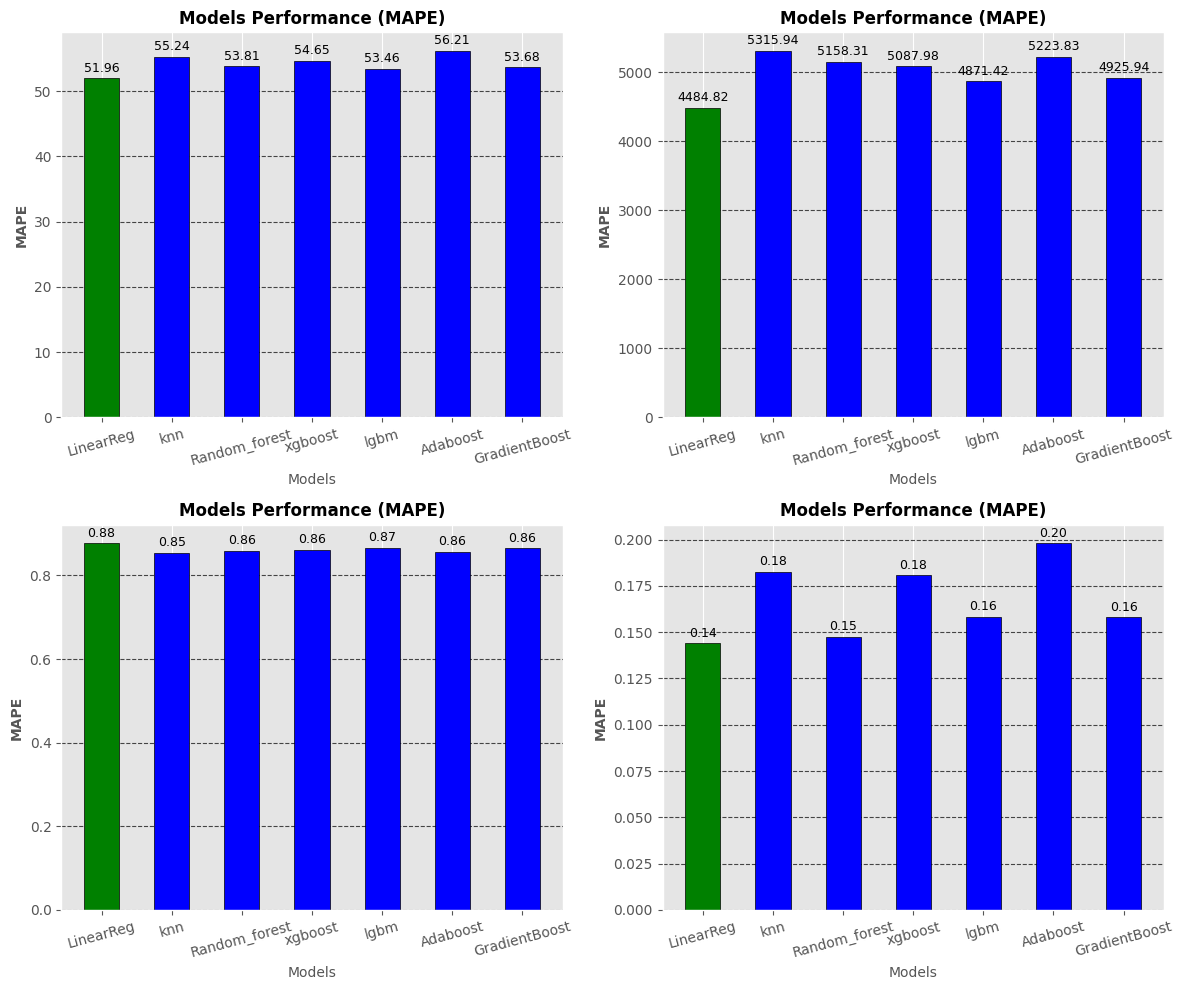

In [40]:
# Plotting Graphs for all results...
grid_rows = 2
grid_cols = 2

plt.figure(figsize=(12, 10))
for index, error in enumerate(error_list):
  plt.subplot(grid_rows, grid_cols, index + 1)
  colors = ['green' if model == best_model_name else 'blue' for model in error.keys()]
  bars = plt.bar(error.keys(), error.values(), color=colors, edgecolor='black', width=0.5)
  for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(error.values())*0.01), f"{yval:.2f}", ha='center', va='bottom', fontsize=9)
  plt.title(f"Models Performance ({cur_metric})", fontsize=12, fontweight='bold')
  plt.xlabel('Models', fontsize=10)
  plt.ylabel(cur_metric, fontsize=10, fontweight='bold')
  plt.grid(axis='y', linestyle='--', color='black',  alpha=0.7)
  plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Let's apply best_model on the Dataset and check predictions...

In [48]:
best_model_obj = model_params[best_model_name]['model'][0]
best_model_obj.fit(x_train, y_train)


LinearRegression()

In [53]:
print(f"best_model(Linear Reg.) train Score: {best_model_obj.score(x_train, y_train)}")
print(f"best_model(Linear Reg.) test Score: {best_model_obj.score(x_test, y_test)}")

best_model(Linear Reg.) train Score: 0.875372094393862
best_model(Linear Reg.) test Score: 0.8769356092678069


In [55]:
best_model_obj.predict(x_test)

array([396.97714965, 286.39372943, 661.24358289, 335.30110875,
       114.32546259, 370.03480829, 182.45216987, 201.19062788,
       461.7637257 , 140.93259779, 358.44864852, 207.85057921,
        36.72709391, 589.83271877, 436.67547711, 377.63483477,
       614.2204224 , 437.11406544, 134.09074172, 379.97224455,
       444.05586694,  40.93313837, 275.89052778, 374.381499  ,
       199.16107593, 610.51156692, 159.35438162, 502.94711542,
       230.61963059, 415.15288989, 338.33831083, 136.36703302,
       448.77424339, 181.62451297, 396.00592401, 334.22752413,
       173.21279296, 148.48473388, 284.55118965, 326.28870876,
       595.13812294, 546.21388936, 495.54842613, 656.15863856,
       635.3902502 , 437.34999936, 288.20855381, 661.79253842,
       306.00733592, 347.67434606, 289.68437966, 157.44037761,
       503.26628363, 249.44415096, 189.51718004, 323.66723125,
       404.65886009, 596.31388497, 612.24028369, 573.63566554,
       491.96811135, 411.95806845, 484.10011954, 403.15

In [57]:
y_test

,Historical_Cost_of_Ride
521,470
737,286
740,552
660,267
411,111
...,...
408,258
332,412
208,552
613,544


In [60]:
comperison = pd.DataFrame({'Actual': y_test, 'Predicted': best_model_obj.predict(x_test)})
comperison.head(10)

,Actual,Predicted
521,470,396.977150
737,286,286.393729
740,552,661.243583
660,267,335.301109
411,111,114.325463
678,359,370.034808
626,173,182.452170
513,196,201.190628
859,555,461.763726
136,163,140.932598


As **Linear Regression** is giving good score and results so it's the best fit model for this Dataset